# Clustering: Learning Without Labels

## 🔗 Where we are in the story

So far every model we have built had one thing in common: **the data came with
labels**.

1. **Bayes / KNN** — we estimated $P(\text{class}\mid \mathbf{x})$ using labels to
   *count* neighbors of each class.
2. **Linear regression** — we fit $\mathbf{w}, b$ by minimizing the gap between
   $\hat{y}$ and the **true** $y$.
3. **Logistic regression** — same idea, but the target was a class label and the
   loss was cross-entropy.

In every case the algorithm was *supervised* — a teacher handed it the answers.

> But what if there are **no answers**? What if all we have is a pile of
> $\mathbf{x}$'s and we want to discover structure in them?

That is **unsupervised learning**, and **clustering** is its flagship tool: group
the points so that *similar* points end up together and *dissimilar* points end up
apart — with nobody telling us what the groups are.

---

# Part 1 — What Is Clustering (and Why Is It Hard)?

## 💡 The goal in one sentence

> Find a partition of the data $\{\mathbf{x}_1, \dots, \mathbf{x}_n\}$ into $K$
> groups $C_1, \dots, C_K$ such that **within-cluster similarity is high** and
> **between-cluster similarity is low**.

Sounds simple — but it hides two thorny questions:

1. **What does "similar" mean?** Euclidean distance? Cosine? Manhattan? The answer
   changes the clusters completely.
2. **How many clusters $K$ are there?** Nobody hands us $K$. We have to *guess* it.

We will spend this notebook answering both.

## 📊 A picture first: three blobs

Let's make some obviously clustered data so we can *see* what clustering is supposed
to do — before the algorithms get involved.

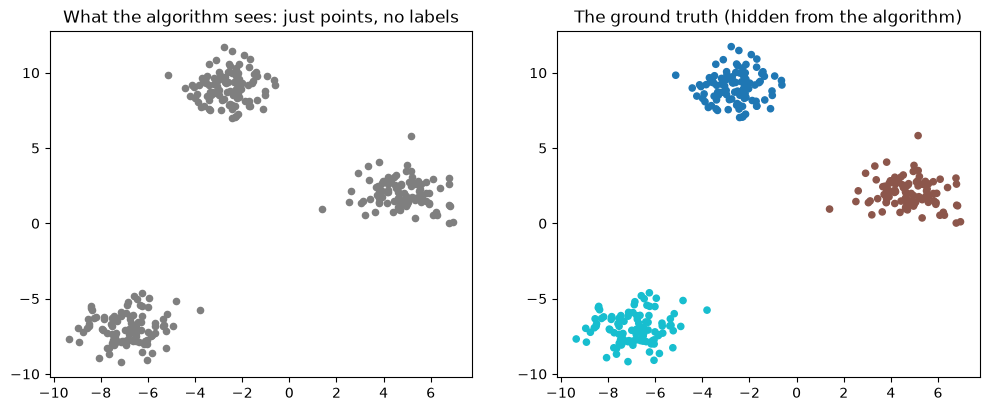

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)

X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.0,
                       random_state=42)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.scatter(X[:, 0], X[:, 1], s=20, c="tab:gray")
ax1.set_title("What the algorithm sees: just points, no labels")
ax2.scatter(X[:, 0], X[:, 1], s=20, c=y_true, cmap="tab10")
ax2.set_title("The ground truth (hidden from the algorithm)")
plt.show()

The left plot is *exactly* what a clustering algorithm receives — no colors, no
labels. The right plot shows the truth we wish to recover. Notice that as humans we
find this *trivial*. The challenge is to make a *machine* do it.

### 🧠 Key takeaway

> Clustering is **ill-posed** without extra assumptions. The same data can be
> reasonably grouped in many ways. Every clustering algorithm is really a particular
> set of assumptions in disguise — and our job is to know which assumptions fit the
> problem.

---

# Part 2 — K-Means: The Workhorse

## 🧩 The idea

K-Means makes a very specific assumption:

> Every cluster is a **ball** (in Euclidean sense), and each ball has a **center**
> $\boldsymbol{\mu}_k$. A point belongs to whichever center it is closest to.

That gives us a clean recipe. Given $K$:

1. **Initialize** $K$ centers $\boldsymbol{\mu}_1, \dots, \boldsymbol{\mu}_K$ (randomly).
2. **Assign** each point to its nearest center:
   $$C_k = \{\mathbf{x}_i : k = \arg\min_j \|\mathbf{x}_i - \boldsymbol{\mu}_j\|^2\}$$
3. **Update** each center to the mean of its assigned points:
   $$\boldsymbol{\mu}_k \leftarrow \frac{1}{|C_k|}\sum_{\mathbf{x} \in C_k} \mathbf{x}$$
4. **Repeat** 2–3 until assignments stop changing.

## 📏 What is K-Means actually optimizing?

It is minimizing the **inertia** (a.k.a. within-cluster sum of squares):

$$J = \sum_{k=1}^{K} \sum_{\mathbf{x} \in C_k} \|\mathbf{x} - \boldsymbol{\mu}_k\|^2$$

So K-Means is *gradient-free gradient descent*: it alternates between two steps,
each of which can only *lower* (or keep) $J$. It is guaranteed to converge — but
only to a **local minimum**, which depends heavily on initialization.

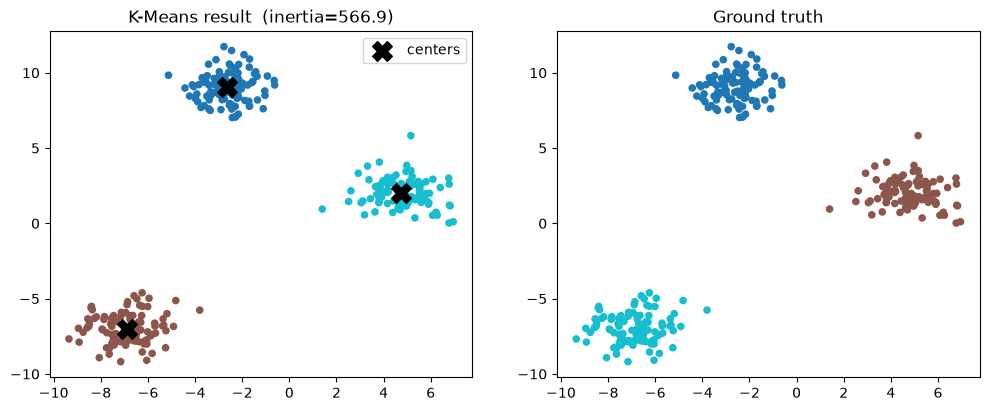

In [2]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
labels = kmeans.fit_predict(X)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.scatter(X[:, 0], X[:, 1], s=20, c=labels, cmap="tab10")
ax1.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c="black", marker="X", label="centers")
ax1.set_title(f"K-Means result  (inertia={kmeans.inertia_:.1f})")
ax1.legend()
ax2.scatter(X[:, 0], X[:, 1], s=20, c=y_true, cmap="tab10")
ax2.set_title("Ground truth")
plt.show()

On this toy data K-Means recovers the clusters almost perfectly. Don't get too
comfortable — real data is messier, as we'll see.

## 🔄 Watch the algorithm iterate

Let's peek inside the loop to build intuition for *how* the centers drift into place:

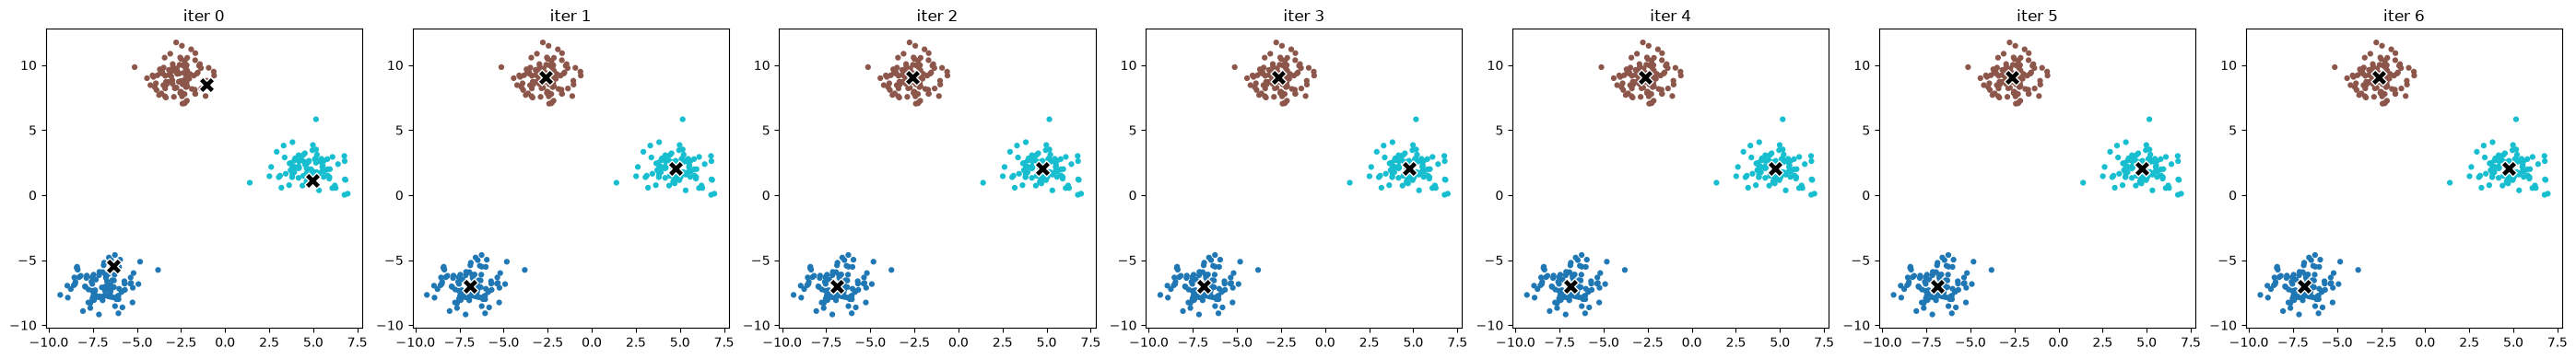

In [3]:
def kmeans_steps(X, K, n_iters=8, seed=0):
    rng = np.random.default_rng(seed)
    centers = X[rng.choice(len(X), K, replace=False)].copy()
    history = [centers.copy()]
    for _ in range(n_iters):
        # assign
        d = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
        labels = d.argmin(axis=1)
        # update
        for k in range(K):
            if np.any(labels == k):
                centers[k] = X[labels == k].mean(axis=0)
        history.append(centers.copy())
    return history

steps = kmeans_steps(X, K=3, n_iters=6, seed=3)

fig, axes = plt.subplots(1, len(steps), figsize=(4 * len(steps), 4))
for ax, centers, i in zip(axes, steps, range(len(steps))):
    d = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
    lab = d.argmin(axis=1)
    ax.scatter(X[:, 0], X[:, 1], s=12, c=lab, cmap="tab10")
    ax.scatter(centers[:, 0], centers[:, 1], s=150, c="black",
               marker="X", edgecolors="white")
    ax.set_title(f"iter {i}")
plt.tight_layout(); plt.show()

Watch the `X` markers march toward the centers of their blobs. After a handful of
iterations they settle — and once they settle, they never move again. That is
convergence.

## ⚠️ K-Means' assumptions (and where they break)

K-Means assumes:

1. Clusters are roughly **spherical** (it uses Euclidean distance).
2. Clusters are of **similar size** (each center "owns" a region by nearest-center,
   which is a Voronoi tessellation — big clusters get a big slice).
3. We **know $K$**.

Let's see what happens when we violate all three with two "moons":

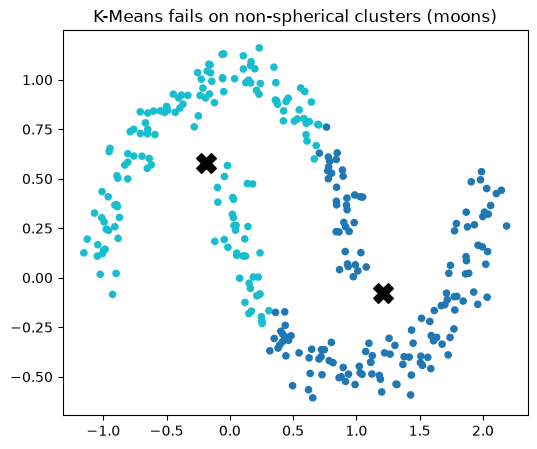

In [4]:
from sklearn.datasets import make_moons

X_moons, _ = make_moons(n_samples=300, noise=0.07, random_state=42)
km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(X_moons)

plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], s=20, c=km.labels_, cmap="tab10")
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            s=200, c="black", marker="X")
plt.title("K-Means fails on non-spherical clusters (moons)")
plt.show()

The moons get sliced straight down the middle, because K-Means can only draw
**linear** (Voronoi) boundaries. The clusters are there — K-Means just isn't
allowed to see them by construction.

---

# Part 3 — Choosing K (When Nobody Tells You)

## 🤔 The fundamental problem

K-Means takes $K$ as input. But who tells us $K$? In real life, nobody.

Here's a tempting-but-broken idea: just pick the $K$ that minimizes inertia.
**That fails** because inertia is *monotonically non-increasing* in $K$ — at the
absurd extreme $K = n$ (every point its own cluster), inertia is exactly $0$.
We'd always "choose" the maximum $K$, which is nonsense.

We need diagnostics that push back.

## 📐 The elbow method

Plot inertia vs. $K$ and look for the "elbow" — the point where adding more clusters
stops buying us much.

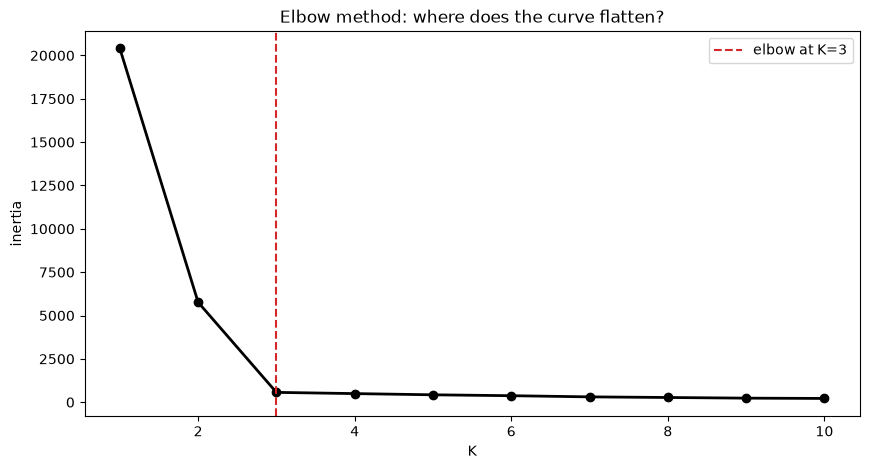

In [5]:
ks = range(1, 11)
inertias = [KMeans(k, n_init=10, random_state=42).fit(X).inertia_ for k in ks]

plt.plot(ks, inertias, "ko-", lw=2)
plt.xlabel("K"); plt.ylabel("inertia")
plt.title("Elbow method: where does the curve flatten?")
plt.axvline(3, color="tab:red", ls="--", label="elbow at K=3")
plt.legend(); plt.show()



## 🧬 DBSCAN: density-based clustering

**Idea:** a cluster is a **dense region** of space, separated from other clusters by
**sparse** regions. No $K$ needed — clusters emerge from the data's shape.

Two parameters:

- $\varepsilon$ (**eps**): the radius around a point to look at neighbors
- $\text{min\_samples}$ : how many neighbors (including itself) make a point a
  **core point**

Rules:

1. A point with $\geq \text{min\_samples}$ neighbors within $\varepsilon$ is a **core point**.
2. Core points within $\varepsilon$ of each other are the **same cluster**.
3. Points in a core point's $\varepsilon$-ball but not core themselves are
   **border points** (join the cluster but don't extend it).
4. Points with too few neighbors and not reachable are **noise** (label $-1$).

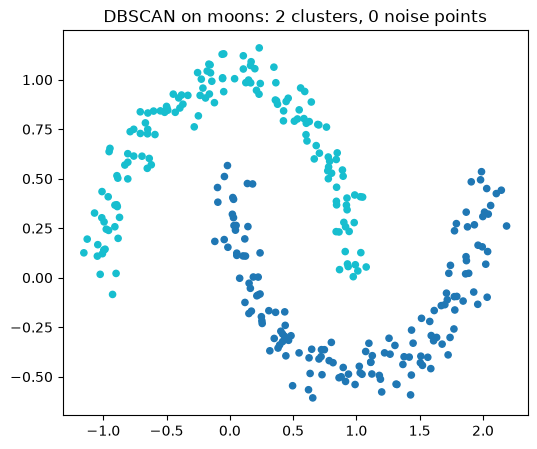

In [8]:
from sklearn.cluster import DBSCAN

# --- DBSCAN on the moons (where K-Means failed) ---
db = DBSCAN(eps=0.2, min_samples=5).fit(X_moons)
plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], s=20, c=db.labels_, cmap="tab10")
plt.title(f"DBSCAN on moons: {len(set(db.labels_) - {-1})} clusters, "
          f"{(db.labels_ == -1).sum()} noise points")
plt.show()